# Project 6 — ARIMA Forecasting on Nifty 50

## Objective
Fit an ARIMA model on Nifty 50 returns to forecast the next 30 trading days
and evaluate forecast accuracy using RMSE and MAE.

## Key Findings
- Raw prices are non-stationary (ADF p = 0.9382) — confirmed d = 1
- Returns are stationary (ADF p = 0.0000)
- PACF shows significant spikes at lags 5 and 6 — weekly trading cycle
- Only AR lags 1 and 5 are statistically significant in the fitted model
- ARIMA captures autocorrelation structure but not directional trend
- Model correctly identifies the weekly cycle (5 trading days = 1 week)

## Model
- **Model:** ARIMA(5, 0, 0) fitted on daily returns
- **Training:** 1201 days (Jan 2019 — Nov 2023)
- **Test:** 30 days (Nov — Dec 2023)

## Results
| Metric | Value |
|--------|-------|
| RMSE | 0.006806 |
| MAE | 0.005001 |
| Actual cumulative return (30 days) | +10.5% |
| Forecasted cumulative return (30 days) | +2.0% |

## Interpretation
ARIMA predicts the statistical mean structure of returns — not directional
market moves. The model correctly stays conservative while the market had
an unusually strong bull run in Nov-Dec 2023. This is expected behavior,
not a model failure.

## Libraries
pandas, numpy, matplotlib, yfinance, statsmodels, sklearn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## Step 1 — Data Download and Preparation
Downloaded 5 years of Nifty 50 daily data using yfinance. 
Computed daily returns via pct_change() — this is the differencing step (d=1).

In [2]:
# Download Nifty 50 data
ticker = yf.Ticker("^NSEI")
df = ticker.history(start="2019-01-01", end="2024-01-01")

# Keep only closing price
df = df[['Close']].copy()

# Calculate daily returns
df['Returns'] = df['Close'].pct_change()

# Drop the first row (NaN return)
df = df.dropna()

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"\nFirst 5 rows:")
print(df.head())




Data shape: (1231, 2)
Date range: 2019-01-03 to 2023-12-29

First 5 rows:
                                  Close   Returns
Date                                             
2019-01-03 00:00:00+05:30  10672.250000 -0.011142
2019-01-04 00:00:00+05:30  10727.349609  0.005163
2019-01-07 00:00:00+05:30  10771.799805  0.004144
2019-01-08 00:00:00+05:30  10802.150391  0.002818
2019-01-09 00:00:00+05:30  10855.150391  0.004906


## Step 2 — Stationarity Test (ADF)
ADF test confirms prices are non-stationary and returns are stationary.
This determines d = 1 for our ARIMA model.

In [3]:
# ADF test on prices
adf_prices = adfuller(df['Close'])
print("=== ADF Test on Raw Prices ===")
print(f"ADF Statistic: {adf_prices[0]:.4f}")
print(f"p-value: {adf_prices[1]:.4f}")
print(f"Conclusion: {'STATIONARY' if adf_prices[1] < 0.05 else 'NOT STATIONARY'}")

print()

# ADF test on returns
adf_returns = adfuller(df['Returns'])
print("=== ADF Test on Returns ===")
print(f"ADF Statistic: {adf_returns[0]:.4f}")
print(f"p-value: {adf_returns[1]:.4f}")
print(f"Conclusion: {'STATIONARY' if adf_returns[1] < 0.05 else 'NOT STATIONARY'}")

=== ADF Test on Raw Prices ===
ADF Statistic: -0.2029
p-value: 0.9382
Conclusion: NOT STATIONARY

=== ADF Test on Returns ===
ADF Statistic: -10.3033
p-value: 0.0000
Conclusion: STATIONARY


## Step 3 — ACF & PACF Analysis
ACF determines q (MA order). PACF determines p (AR order).
Significant spikes at lags 5-6 confirm the weekly trading cycle.

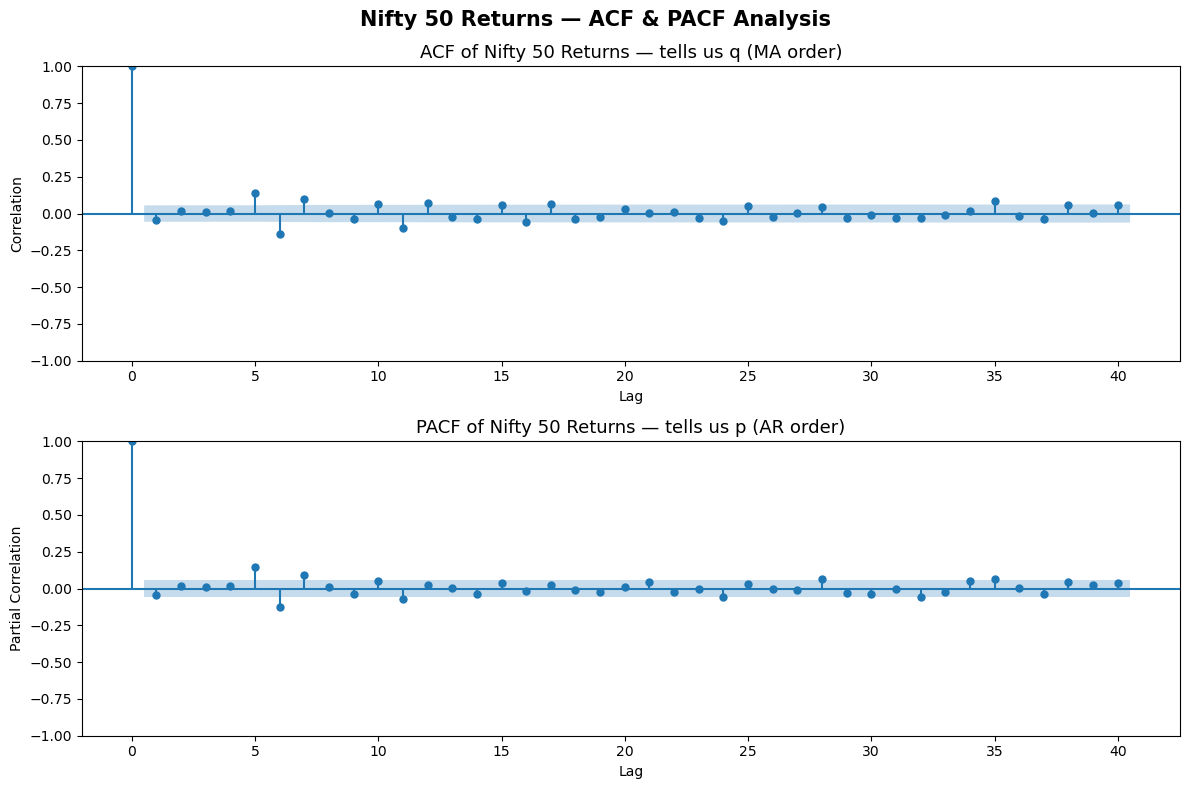

Confidence band threshold: ± 0.0559


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot
plot_acf(df['Returns'], lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Nifty 50 Returns — tells us q (MA order)', fontsize=13)
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlation')

# PACF plot
plot_pacf(df['Returns'], lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF of Nifty 50 Returns — tells us p (AR order)', fontsize=13)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Correlation')

plt.suptitle('Nifty 50 Returns — ACF & PACF Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confidence band threshold: ±", round(1.96/np.sqrt(len(df['Returns'])), 4))

## Step 4 — Model Fitting
ARIMA(5,0,0) fitted on training returns.
AR lags 1 and 5 are statistically significant (p < 0.05).

In [5]:
# Use returns for modelling
returns = df['Returns'].copy()

# Train/test split — use last 30 days as test
train = returns[:-30]
test = returns[-30:]

print(f"Training size: {len(train)} days")
print(f"Test size: {len(test)} days")
print(f"Training period: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test period: {test.index[0].date()} to {test.index[-1].date()}")

# Fit ARIMA(5,1,0) — on returns which are already differenced
# Since returns = first difference of prices, d=0 here on returns directly
model = ARIMA(train, order=(5, 0, 0))
fitted_model = model.fit()

print("\n=== Model Summary ===")
print(fitted_model.summary())

Training size: 1201 days
Test size: 30 days
Training period: 2019-01-03 to 2023-11-15
Test period: 2023-11-16 to 2023-12-29

=== Model Summary ===
                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                 1201
Model:                 ARIMA(5, 0, 0)   Log Likelihood                3608.428
Date:                Mon, 13 Apr 2026   AIC                          -7202.857
Time:                        23:27:20   BIC                          -7167.220
Sample:                             0   HQIC                         -7189.433
                               - 1201                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.245      0.213      -0.

## Step 5 — Forecasting and Evaluation
30-day out-of-sample forecast evaluated using RMSE and MAE.

In [6]:
# Forecast 30 days ahead
forecast_result = fitted_model.forecast(steps=30)
forecast_returns = forecast_result.values

# Get actual returns for comparison
actual_returns = test.values

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(actual_returns, forecast_returns))
mae = mean_absolute_error(actual_returns, forecast_returns)

print(f"=== Forecast Evaluation ===")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"\nMean actual return:   {actual_returns.mean():.6f}")
print(f"Mean forecast return: {forecast_returns.mean():.6f}")

=== Forecast Evaluation ===
RMSE: 0.006806
MAE:  0.005001

Mean actual return:   0.003338
Mean forecast return: 0.000633


## Step 6 — Visualization
Two plots — daily returns comparison and cumulative returns comparison.

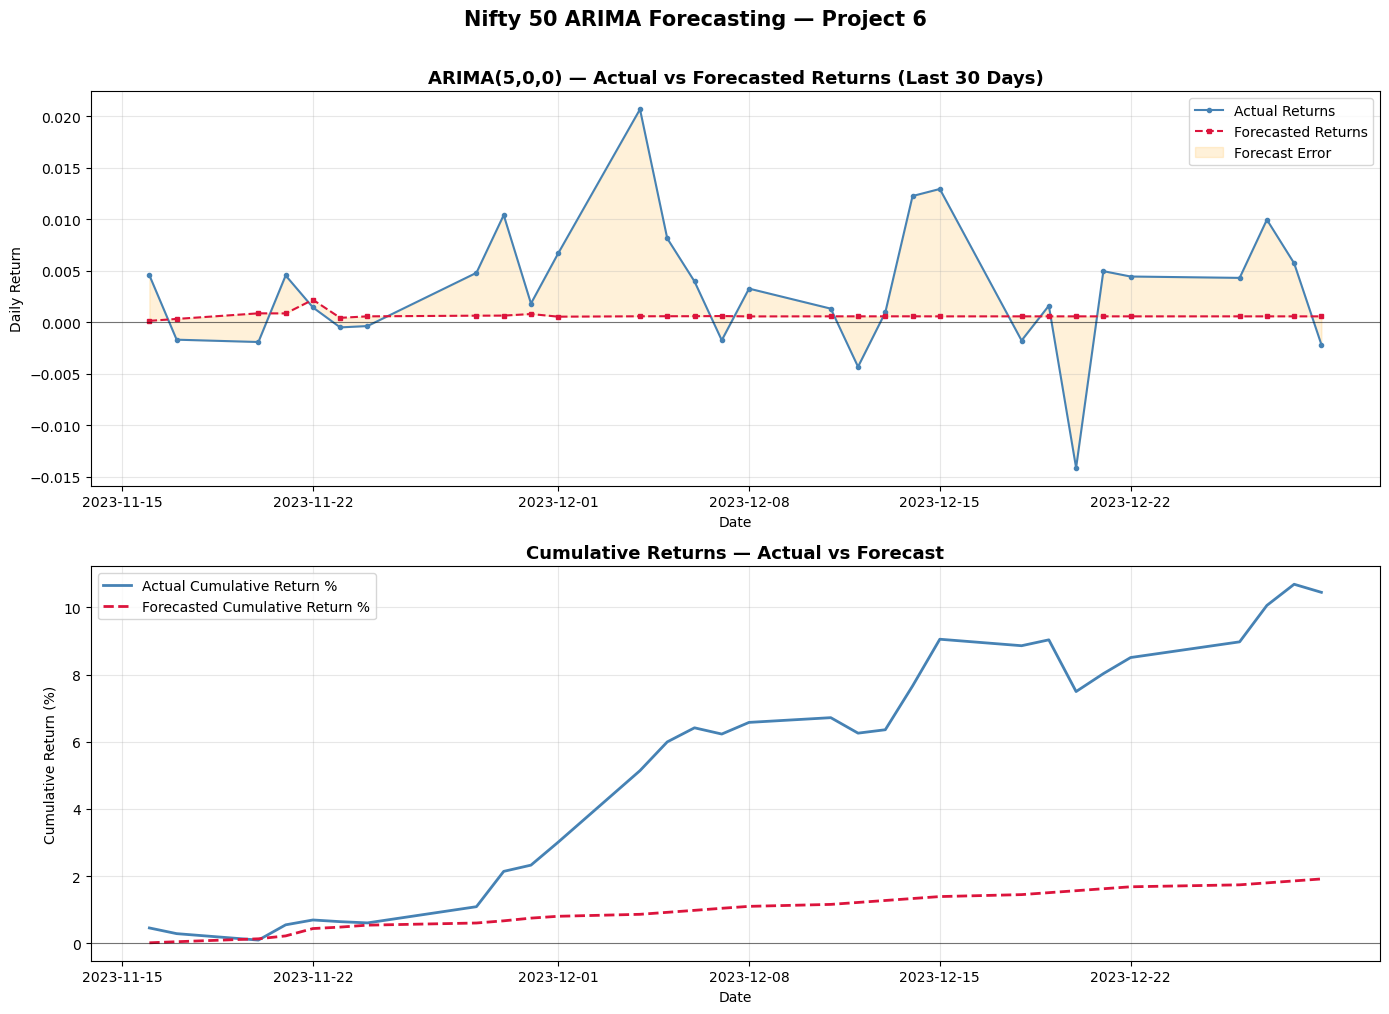

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Actual vs Forecast Returns
ax1 = axes[0]
ax1.plot(test.index, actual_returns, 
         color='steelblue', linewidth=1.5, 
         label='Actual Returns', marker='o', markersize=3)
ax1.plot(test.index, forecast_returns, 
         color='crimson', linewidth=1.5, 
         label='Forecasted Returns', marker='s', markersize=3, linestyle='--')
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
ax1.fill_between(test.index, actual_returns, forecast_returns, 
                  alpha=0.15, color='orange', label='Forecast Error')
ax1.set_title('ARIMA(5,0,0) — Actual vs Forecasted Returns (Last 30 Days)', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Return')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2 — Cumulative Returns Comparison
cumulative_actual = (1 + pd.Series(actual_returns, index=test.index)).cumprod() - 1
cumulative_forecast = (1 + pd.Series(forecast_returns, index=test.index)).cumprod() - 1

ax2 = axes[1]
ax2.plot(test.index, cumulative_actual * 100, 
         color='steelblue', linewidth=2, label='Actual Cumulative Return %')
ax2.plot(test.index, cumulative_forecast * 100, 
         color='crimson', linewidth=2, linestyle='--', 
         label='Forecasted Cumulative Return %')
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
ax2.set_title('Cumulative Returns — Actual vs Forecast', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Nifty 50 ARIMA Forecasting — Project 6', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('arima_forecast_results.png', dpi=150, bbox_inches='tight')
plt.show()